In [1]:
import warnings
warnings.filterwarnings('ignore')

In [7]:
# ==========================================
# CELL 1: KHAI BÁO THƯ VIỆN & LÀM SẠCH DỮ LIỆU
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Đọc file dữ liệu gốc dạng CSV
FILE_INPUT = 'data.csv'
df_raw = pd.read_csv(FILE_INPUT, header=None)

# Trích xuất thông tin định danh sinh viên (bắt đầu từ cột index 3)
mssv_list = df_raw.iloc[1, 3:].tolist()
name_list = df_raw.iloc[2, 3:].tolist()
grade_data = df_raw.iloc[4:, 3:].copy() 

# Hàm chuẩn hóa điểm hệ 4 (Xử lý các dấu phẩy và ký tự bỏ thi, trống)
def chuan_hoa_diem(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower().replace('nan', '').replace(',', '.')
    if s in ['-', '—', 'x', '']: return np.nan
    try:
        f = float(s)
        return f if 0 <= f <= 4.0 else np.nan
    except: return np.nan

# Làm sạch toàn bộ bảng điểm
clean_grades = grade_data.map(chuan_hoa_diem)

# Chuyển đổi ma trận điểm: Dòng = Sinh viên, Cột = Điểm các môn
features_df = clean_grades.T
features_df.columns = [f"Mon_{i}" for i in range(features_df.shape[1])]
features_df.insert(0, 'MSSV', mssv_list)
features_df.insert(1, 'Ho_va_ten', name_list)

# Kết hợp MSSV và Họ Tên thành 1 nhãn định danh duy nhất để hiển thị trực quan
features_df['Sinh_Vien'] = features_df['MSSV'].astype(str) + " - " + features_df['Ho_va_ten'].astype(str)

# Loại bỏ sinh viên hoàn toàn không có điểm môn nào
features_df = features_df.dropna(subset=features_df.columns[2:-1], how='all').reset_index(drop=True)

# Tính GPA thực tế để hỗ trợ sắp xếp và hiển thị báo cáo
student_gpa = clean_grades.mean(axis=0).round(2)
gpa_map = dict(zip(mssv_list, student_gpa))
features_df['GPA'] = features_df['MSSV'].map(gpa_map)

# Điền khuyết các ô thiếu (NaN) bằng điểm trung bình của môn học đó
X_features = features_df.iloc[:, 2:-2].copy()
X_features = X_features.fillna(X_features.mean().fillna(2.0)).values

print(f"Đã làm sạch xong dữ liệu cho {len(features_df)} sinh viên.")
display(features_df[['Sinh_Vien', 'GPA']])

Đã làm sạch xong dữ liệu cho 66 sinh viên.


,Sinh_Vien,GPA
0,K225480106002 - Nguyễn Tuấn Anh,2.47
1,K225480106095 - Nguyễn Tuấn Anh,2.30
2,K225510201001 - Bùi Ngọc Anh,2.25
3,K225480106082 - Vũ Việt Anh,2.24
4,K225480106001 - Lê Tuấn Anh,2.50
...,...,...
61,K225480106067 - Nguyễn Đình Tú,2.61
62,K225480106068 - Vũ Đức Tú,2.60
63,K225480106075 - Nguyễn Đức Việt,2.72
64,K225480106074 - Nguyễn Hoàng Việt,2.80


In [3]:
# ==========================================
# CELL 2: PHÂN CỤM K-MEANS & XẾP HẠNG NĂNG LỰC
# ==========================================
# Khởi chạy thuật toán phân thành 3 cụm
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_df['Cluster_ID'] = kmeans.fit_predict(X_features)

# Xếp hạng cụm theo thứ tự năng lực học tập dựa vào GPA thực tế giảm dần
cluster_gpa_means = features_df.groupby('Cluster_ID')['GPA'].mean()
sorted_clusters = cluster_gpa_means.sort_values(ascending=False).index

cluster_labels = {
    sorted_clusters[0]: 'Cụm A (Sinh viên Giỏi)',
    sorted_clusters[1]: 'Cụm B (Sinh viên Khá)',
    sorted_clusters[2]: 'Cụm C (Sinh viên Trung Bình Yếu)'
}
features_df['Phan_cum'] = features_df['Cluster_ID'].map(cluster_labels)

print("Đã hoàn tất phân cụm dữ liệu.")

Đã hoàn tất phân cụm dữ liệu.


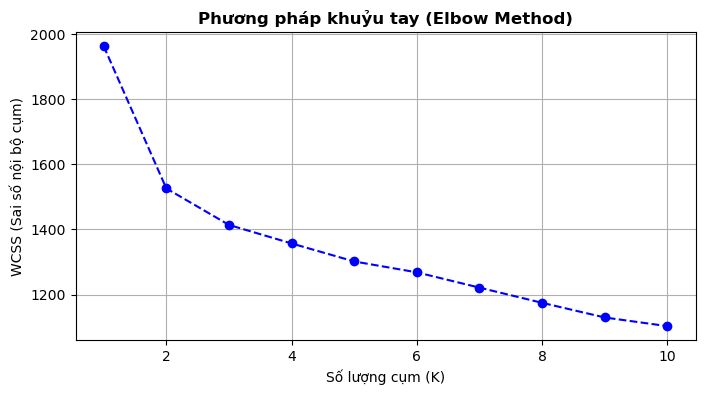

In [4]:
# ==========================================
# CELL 3: ĐỒ THỊ KHUỶU TAY (ELBOW METHOD)
# ==========================================
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=10)
    km.fit(X_features)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp khuỷu tay (Elbow Method)', fontsize=12, fontweight='bold')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS (Sai số nội bộ cụm)')
plt.grid(True)
plt.show()

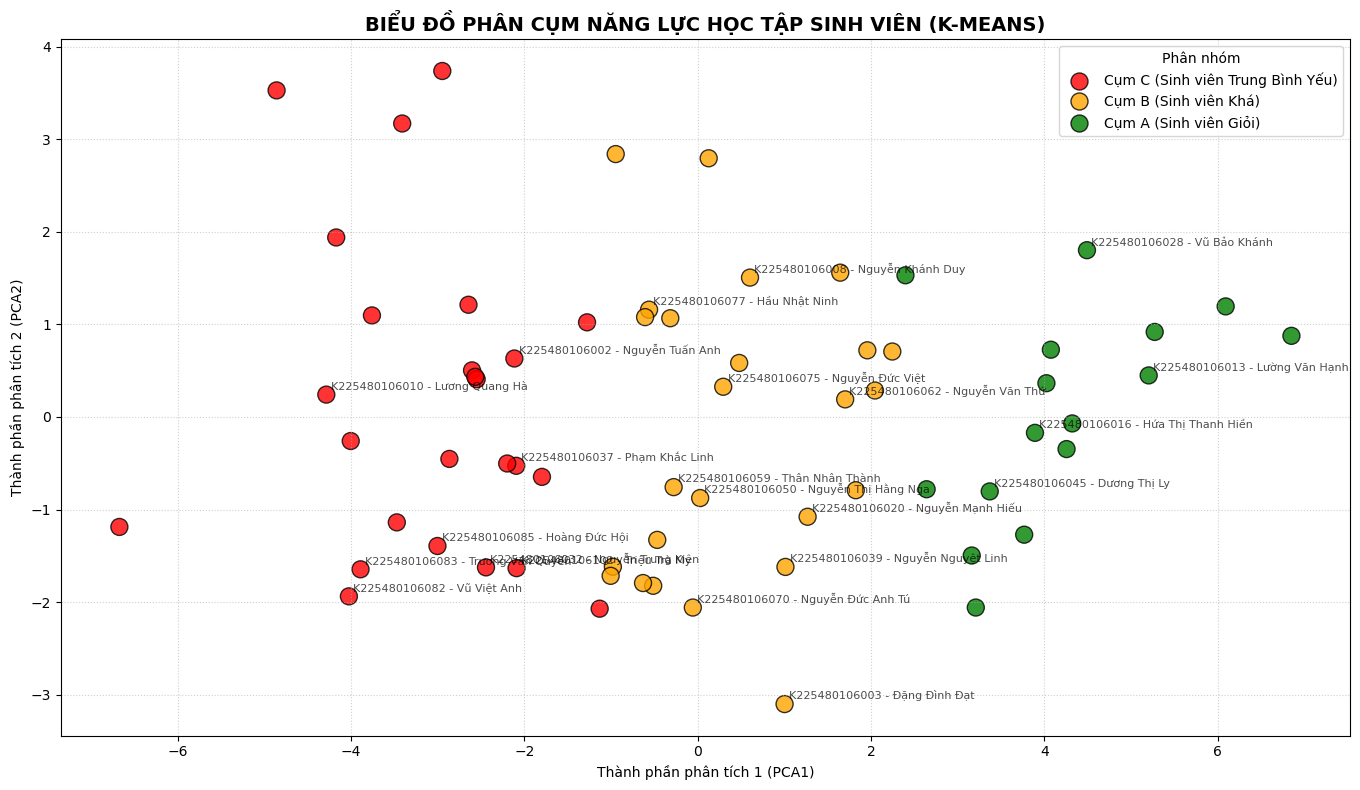

In [5]:
# ==========================================
# CELL 4: VẼ BIỂU ĐỒ PHÂN CỤM TOÀN LỚP
# ==========================================
# Sử dụng PCA giảm chiều dữ liệu môn học xuống 2 chiều để biểu diễn lên đồ thị
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_features)
features_df['PCA1'] = X_pca[:, 0]
features_df['PCA2'] = X_pca[:, 1]

# Vẽ biểu đồ rải rác (Scatter Plot)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=features_df,
    x='PCA1', y='PCA2',
    hue='Phan_cum',
    palette={'Cụm A (Sinh viên Giỏi)': 'green', 
             'Cụm B (Sinh viên Khá)': 'orange', 
             'Cụm C (Sinh viên Trung Bình Yếu)': 'red'},
    s=150, alpha=0.8, edgecolors='black'
)

# Hiển thị tên của một số sinh viên tiêu biểu lên biểu đồ để nhận diện trực quan
for i in range(len(features_df)):
    if i % 3 == 0: # Tránh đè chữ bằng cách hiển thị cách quãng nhãn tên
        plt.text(
            features_df['PCA1'][i] + 0.05, 
            features_df['PCA2'][i] + 0.05, 
            features_df['Sinh_Vien'][i], 
            fontsize=8, alpha=0.7
        )

plt.title('BIỂU ĐỒ PHÂN CỤM NĂNG LỰC HỌC TẬP SINH VIÊN (K-MEANS)', fontsize=14, fontweight='bold')
plt.xlabel('Thành phần phân tích 1 (PCA1)')
plt.ylabel('Thành phần phân tích 2 (PCA2)')
plt.legend(title='Phân nhóm')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [6]:
# ==========================================
# CELL 5: XUẤT DANH SÁCH BÁO CÁO CHI TIẾT
# ==========================================
print("=== THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO CỤM ===")
print(features_df['Phan_cum'].value_counts().to_string())
print("\n" + "="*70 + "\n")

# Sắp xếp và in danh sách chi tiết từng nhóm học lực
for label in ['Cụm A (Sinh viên Giỏi)', 'Cụm B (Sinh viên Khá)', 'Cụm C (Sinh viên Trung Bình Yếu)']:
    sub_cluster = features_df[features_df['Phan_cum'] == label].copy()
    sub_cluster = sub_cluster.sort_values(by='GPA', ascending=False).reset_index(drop=True)
    
    print(f"--- DANH SÁCH: {label.upper()} ---")
    print(f"Sĩ số nhóm: {len(sub_cluster)} sinh viên")
    print(f"GPA trung bình của nhóm: {sub_cluster['GPA'].mean():.2f}")
    print("\nChi tiết danh sách thành viên:")
    
    # Thiết lập cột định danh làm chỉ mục để in ra màn hình rõ ràng
    sub_cluster_printed = sub_cluster.set_index('Sinh_Vien')
    display(sub_cluster_printed[['GPA']])
    print("\n" + "-"*60 + "\n")

=== THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO CỤM ===
Phan_cum
Cụm C (Sinh viên Trung Bình Yếu)    25
Cụm B (Sinh viên Khá)               25
Cụm A (Sinh viên Giỏi)              16


--- DANH SÁCH: CỤM A (SINH VIÊN GIỎI) ---
Sĩ số nhóm: 16 sinh viên
GPA trung bình của nhóm: 3.21

Chi tiết danh sách thành viên:


,GPA
Sinh_Vien,
K225480106009 - Trần Thị Thu Hà,3.55
K225480106053 - Hoàng Kim Ngọc,3.44
K225480106019 - Nguyễn Trung Hiếu,3.35
K225480106013 - Lường Văn Hạnh,3.34
K225480106058 - Nguyễn Tiến Thắng,3.25
K225480106015 - Nguyễn Thị Thu Hiền,3.25
K225480106093 - Nguyễn Đức Dương,3.24
K225480106056 - Hoàng Thị Quyến,3.21
K225480106099 - Đậu Văn Khánh,3.18



------------------------------------------------------------

--- DANH SÁCH: CỤM B (SINH VIÊN KHÁ) ---
Sĩ số nhóm: 25 sinh viên
GPA trung bình của nhóm: 2.75

Chi tiết danh sách thành viên:


,GPA
Sinh_Vien,
K225480106057 - Phạm Mạnh Quỳnh,3.00
K225480106100 - Lý Văn Cường,2.99
K225480106027 - Hầu Thị Thanh Huyền,2.98
K225480106040 - Nguyễn Thị Linh,2.96
K225480106039 - Nguyễn Nguyệt Linh,2.95
K225480106062 - Nguyễn Văn Thứ,2.95
K225480106011 - Ngụy Đình Tuấn Hà,2.90
K225480106003 - Đặng Đình Đạt,2.87
K225480106020 - Nguyễn Mạnh Hiếu,2.81



------------------------------------------------------------

--- DANH SÁCH: CỤM C (SINH VIÊN TRUNG BÌNH YẾU) ---
Sĩ số nhóm: 25 sinh viên
GPA trung bình của nhóm: 2.30

Chi tiết danh sách thành viên:


,GPA
Sinh_Vien,
K225480106043 - Nguyễn Giang Long,2.55
K225480106054 - Nguyễn Thị Xuân Phương,2.55
K225480106001 - Lê Tuấn Anh,2.50
K225480106037 - Phạm Khắc Linh,2.48
K225480106002 - Nguyễn Tuấn Anh,2.47
K225480106102 - Triệu Trà My,2.46
K225480106060 - Nguyễn Thu Thảo,2.43
K225480106076 - Nguyễn Lam Sơn,2.42
K225480106032 - Nguyễn Trung Kiên,2.41



------------------------------------------------------------

